In [1]:
!pip install unsloth transformers datasets evaluate scikit-learn trl seaborn matplotlib --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_NAME   = "microsoft/deberta-v3-large"
DATA_DIR     = "/content/drive/MyDrive/nlpcc/data"
OUTPUT_DIR   = "/content/drive/MyDrive/nlpcc/outputs/encoder"
BATCH_SIZE   = 16
MAX_LENGTH   = 512
LR           = 5e-5
NUM_EPOCHS   = 15
LORA_R       = 16
LORA_ALPHA   = 32
SEED         = 3407

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import json
import os
from collections import Counter

VALUE_LABELS = [
    "Self-direction\u2013thought",
    "Self-direction\u2013action",
    "Stimulation",
    "Hedonism",
    "Achievement",
    "Power\u2013dominance",
    "Power\u2013resources",
    "Face",
    "Security\u2013personal",
    "Security\u2013societal",
    "Tradition",
    "Conformity\u2013rules",
    "Conformity\u2013interpersonal",
    "Humility",
    "Benevolence\u2013dependability",
    "Benevolence\u2013caring",
    "Universalism\u2013concern",
    "Universalism\u2013nature",
    "Universalism\u2013tolerance",
]
NUM_CLASSES = len(VALUE_LABELS)
label2id = {v:i for i, v in enumerate(VALUE_LABELS)}
id2label = {i:v for i, v in enumerate(VALUE_LABELS)}
print(f"num of classes:{NUM_CLASSES}")

train_vals = []
with open(os.path.join(DATA_DIR, "train.jsonl")) as f:
  for line in f:
    train_vals.append(json.loads(line)["Value"])

counter = Counter(train_vals)
print("Train class distribution:\n")
for label in VALUE_LABELS:
  print(f"{label} : {counter[label]}")

num of classes:19
Train class distribution:

Self-direction–thought : 119
Self-direction–action : 124
Stimulation : 400
Hedonism : 164
Achievement : 174
Power–dominance : 156
Power–resources : 237
Face : 258
Security–personal : 202
Security–societal : 70
Tradition : 90
Conformity–rules : 385
Conformity–interpersonal : 236
Humility : 100
Benevolence–dependability : 189
Benevolence–caring : 317
Universalism–concern : 160
Universalism–nature : 71
Universalism–tolerance : 68


In [4]:
import json
import torch
import numpy as np
from datasets import Dataset

def build_text(row):
  """将train.jsonl里每一行数据中的Scenario / Question / Consistent Value Response拼接为一份text字符串"""
  parts = []
  if row.get("Scenario"):
    parts.append("Scenario: " + row["Scenario"].strip())
  if row.get("Question"):
    parts.append("Question: " + row["Question"].strip())
  if row.get("Consistent Value Response"):
    parts.append("Response: " + row["Consistent Value Response"].strip())
  return " [SEP] ".join(parts)

def load_jsonl(path, has_label = True):
  """传入数据集文件路径将文件转化为方便处理的数据集（字典格式），同时设置has_label布尔变量处理无标签的数据集（测试集）"""
  texts, labels = [], []
  with open(path) as f:
    for line in f:
      row = json.loads(line) # 将JSON格式的字符串转换为python字典
      texts.append(build_text(row))
      if has_label:
        labels.append(label2id[row["Value"]])
  if has_label:
    return Dataset.from_dict({"text":texts, "labels":labels})
  return Dataset.from_dict({"text": texts})

# 加载数据
train_dataset = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"))
dev_dataset = load_jsonl(os.path.join(DATA_DIR, "dev.jsonl"))
print(f"Train Data Size: {len(train_dataset)}")
print(f"Dev Data Size: {len(dev_dataset)}")
print(f"text example: {train_dataset[0]['text'][:300]}")

Train Data Size: 3520
Dev Data Size: 514
text example: Scenario: You work in a corporate setting where your manager frequently imposes strict guidelines. [SEP] Question: How would you handle a disagreement with a superior during a team meeting? [SEP] Response: I would suggest alternative solutions diplomatically, ensuring my input is heard without chall


In [5]:
# Cell 5: 加载模型 + Tokenizer
import torch
from unsloth import FastModel
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding

model, tokenizer = FastModel.from_pretrained(
    model_name=MODEL_NAME,
    load_in_4bit=False,
    max_seq_length=MAX_LENGTH,
    dtype=torch.bfloat16,
    auto_model=AutoModelForSequenceClassification,
    num_labels=NUM_CLASSES,
)

model.config.id2label = id2label
model.config.label2id = label2id

def tokenize_fn(examples):
    return tokenizer(examples["text"], max_length=MAX_LENGTH, truncation=True)

train_dataset = train_dataset.map(tokenize_fn, batched=True)
dev_dataset   = dev_dataset.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Deberta_V2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias       

Map:   0%|          | 0/3520 [00:00<?, ? examples/s]

Map:   0%|          | 0/514 [00:00<?, ? examples/s]

Total parameters: 435,081,235


In [6]:
model = FastModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    task_type="SEQ_CLS",
)


Unsloth: Allowing gradients for `base_model.model.classifier` since it's in `modules_to_save`.


In [7]:
# Cell 7: 训练（WeightedTrainer 处理类别不均衡）
import evaluate
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from transformers import TrainingArguments, Trainer

# 计算类别权重
train_labels = np.array(train_dataset["labels"])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Class weights (first 5):", class_weights[:5].round(3))

# 自定义 Trainer，使用加权交叉熵
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=class_weights_tensor)
        return (loss, outputs) if return_outputs else loss

# 评估指标
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": f1}

# 训练参数
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=1,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=0.1,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_torch",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=SEED,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=20,
    label_names=["labels"],
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer_stats = trainer.train()
print(trainer_stats)

Class weights (first 5): [1.557 1.494 0.463 1.13  1.065]


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,520 | Num Epochs = 15 | Total steps = 3,300
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 3,165,203 of 438,246,438 (0.72% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,2.898569,2.906413,0.130350,0.093538
2,2.435242,2.448123,0.326848,0.258973
3,1.735110,1.682847,0.649805,0.619009
4,1.200316,1.175450,0.747082,0.725650
5,0.766247,0.781244,0.857977,0.854149
6,0.538157,0.528011,0.920233,0.910252
7,0.424468,0.432085,0.920233,0.911160
8,0.334497,0.373172,0.926070,0.917659
9,0.290679,0.352503,0.920233,0.912665
10,0.231959,0.335502,0.922179,0.912248


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-220/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-440/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-660/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-880/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-1100/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-1320/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/nlpcc/outputs/encoder/checkpoint-1540/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content

TrainOutput(global_step=3300, training_loss=0.8654461980588508, metrics={'train_runtime': 1662.5144, 'train_samples_per_second': 31.759, 'train_steps_per_second': 1.985, 'total_flos': 1.1472615758064e+16, 'train_loss': 0.8654461980588508, 'epoch': 15.0})


Dev Set Evaluation Results
                           precision    recall  f1-score   support

   Self-direction–thought     0.8000    0.7059    0.7500        17
    Self-direction–action     0.7895    0.8333    0.8108        18
              Stimulation     0.9828    0.9828    0.9828        58
                 Hedonism     1.0000    1.0000    1.0000        24
              Achievement     0.9259    0.9615    0.9434        26
          Power–dominance     0.9565    0.9565    0.9565        23
          Power–resources     0.9714    0.9714    0.9714        35
                     Face     0.9714    0.9189    0.9444        37
        Security–personal     0.9310    0.9310    0.9310        29
        Security–societal     1.0000    1.0000    1.0000        11
                Tradition     1.0000    0.9286    0.9630        14
         Conformity–rules     0.9474    0.9818    0.9643        55
 Conformity–interpersonal     0.8649    0.9412    0.9014        34
                 Humility     1.00

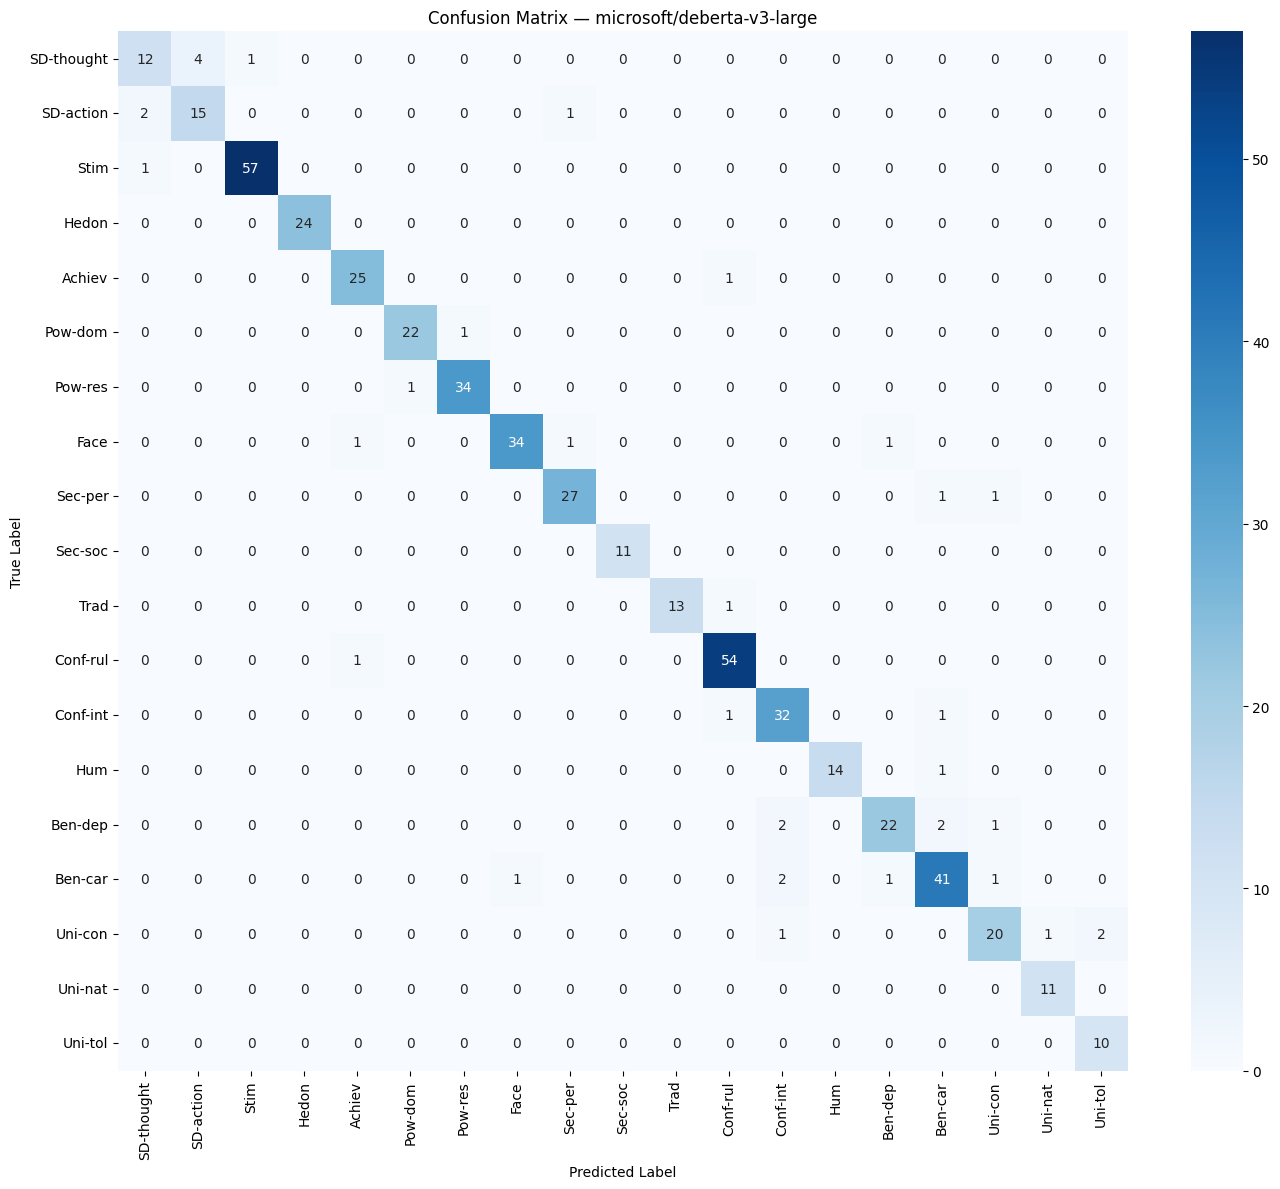

Confusion matrix saved to /content/drive/MyDrive/nlpcc/outputs/encoder/confusion_matrix.png


In [8]:
# Cell 8: Dev 集综合评估 + 每类 F1 + 混淆矩阵热图
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

pred_output = trainer.predict(dev_dataset)
preds  = np.argmax(pred_output.predictions, axis=-1)
labels = np.array(dev_dataset["labels"])

print("=" * 60)
print("Dev Set Evaluation Results")
print("=" * 60)
print(classification_report(
    labels, preds,
    target_names=VALUE_LABELS,
    digits=4
))

# 混淆矩阵热图
cm = confusion_matrix(labels, preds)
short_labels = [
    "SD-thought", "SD-action", "Stim", "Hedon", "Achiev",
    "Pow-dom", "Pow-res", "Face", "Sec-per", "Sec-soc",
    "Trad", "Conf-rul", "Conf-int", "Hum", "Ben-dep",
    "Ben-car", "Uni-con", "Uni-nat", "Uni-tol"
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_labels, yticklabels=short_labels
)
plt.title(f"Confusion Matrix — {MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()
print(f"Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix.png")